In [5]:
import numpy as np
import matplotlib.pyplot as plt

n=100
Lx=20
Ly=20

D=0.0000178 #Diffusivité de O2 dans l'air
W=0.0000593 #Perméabilité de la membrane
Pi=150 #Pression partielle en mmHg
C_0=5.8*(10e-6)*150 #Concentration en O2 en mol/m3

dx=(Lx/(n-1))
dy=(Ly/(n-1))

lamda=D/W
a=(Lx/Ly)

def bijection(i,j):
    return i+(n*j)
def reciproque(k):
    i=k%n
    j=(k-i)/n
    return [i,j]

c=np.zeros((n*n,n*n))
h=np.zeros(n*n)
b=np.zeros((n,n))

for i in range(0,n):
    k=bijection(i,n-1)
    c[k][k]=1
    h[k]=C_0
for i in range(1,n-1):
    c[i][i]=-(2+a-((a*dy)/lamda))
    c[i][i+1]=1
    c[i][i-1]=1
    c[i][i+n]=a
for i in range(1,n-1):
    for j in range(1,n-1):
        k=bijection(i,j)
        c[k][k]=-(2+(2*a))
        c[k][k+1]=1
        c[k][k-1]=1
        c[k][k+n]=a
        c[k][k-n]=a
for j in range(1,n-1):
    k=bijection(0,j)
    c[k][k]=-(1+(2*a))
    c[k][k+1]=1
    c[k][k+n]=1
    c[k][k-n]=a
for j in range(1,n-1):
    k=bijection(n-1,j)
    c[k][k]=-(1+(2*a))
    c[k][k-1]=1
    c[k][k+n]=a
    c[k][k-n]=a

f=bijection(0,0)
c[f][f]=-(1+(2*a)-(a*(1+(dy/lamda))))
c[f][f+1]=1
c[f][f+n]=a

g=bijection(n-1,0)
c[g][g]=-(1+(2*a)-(a*(1+(dy/lamda))))
c[g][g-1]=1
c[g][g+n]=a

X=np.dot(np.linalg.inv(c),h)

for k in range(0,n*n):
    l=reciproque(k)
    i=l[0]
    j=int(l[1])
    b[j,i]=X[k]

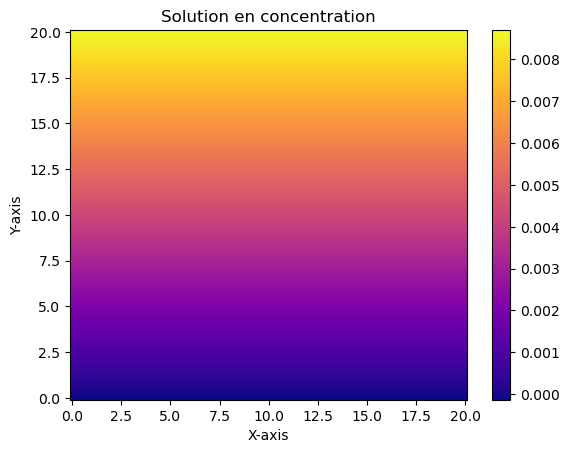

In [6]:
x = np.linspace(0, Lx, n)
y = np.linspace(0, Ly, n)
Z, Y = np.meshgrid(x, y)
# Plotting the results
plt.pcolormesh(Z, Y, b, cmap='plasma')  # You can also use plt.pcolormesh for a different style
#plt.contourf(Z, Y, b, cmap='plasma')  # You can also use plt.pcolormesh for a different style
plt.colorbar()  # Add a colorbar for reference
plt.title('Solution en concentration')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [ ]:
import numpy as np
import numpy.linalg as alg
import matplotlib.pyplot as plt

n=100
m=100

def bij_ind(n,m):             #matrice des indice
    L=np.zeros([n,m])
    for i in range(0,n):
        for j in range(0,m):
            L[i][j]=j+m*(i)
    return L
print(bij_ind(n,m))
def voisinsdek(n,m):          #matrice des indice
    M=[]
    for k in range(0,n*m):
        M.append( [k - 1, k + 1, k - m, k + m])    #indices des voisins du point d'indice k
    for i in range(0,n*m):
        k=i+1
        #si les voinsins n'existent pas
        if i//m==0 :          
            M[i][2]=None    # pas de voisins en haut
        if i//m==n-1 :
            M[i][3]=None    # pas de voisins en bas
        if (i%m)==-1:
            M[i][1]=None    # pas de voisins à droite
        if (i%m)==0:
            M[i][0]=None    # pas de voisins à gauche
    return np.array(M)      #liste des listes des indices des voinsins (la ligne M[k] contient les indices des voinsins du point d'indice k)
print(voisinsdek(5,5))

def nombrevoisinsnonnul(n,m,k):
    a=0
    for i in voisinsdek(n,m)[k]:  #(la ligne M[k] contient les indices des voinsins du point d'indice k)
        if i != None:
            a+=1
    return -a
print(nombrevoisinsnonnul(4,3,1))
def MATRICE(n,m):
    A=np.zeros([n*m,n*m])
    for i in range(0,n*m):
        for j in range(0,n*m):
            if i<m:
                A[i][i]=1        #car C=C0 sur la frontière de l'entrée
            else:
                if i==j:
                    A[i][i]=nombrevoisinsnonnul(n,m,i)     #sur la diagonale, on a -(le nombre de voisins non nuls)
                elif j in voisinsdek(n,m)[i]:              #si j est égale à l'un des indices des voisins du point d'indice i
                    A[i][j]=1
            if i>=(n-1)*m:
                A[i][i]=-17          #condition aux limites de Robin
    return A

M=MATRICE(n,m)
print(MATRICE(n,m))
O=np.zeros(n*m)
for i in range(m):
    O[i]=10                    #C0

X=alg.solve(M,O)
print(O)
print(X)


def bijinv(X, n, m):    #transformer la solution en matrice
    L = np.zeros((n, m))
    c = len(X)
    for j in range(c):
        L[j // m][j % m] = X[j]
    return L
print(bijinv(X,n,m))
plt.imshow(bijinv(X,n,m))

# Ajouter une barre de couleur pour indiquer les valeurs
plt.colorbar()

# Afficher le tracé
plt.show()



[[0.000e+00 1.000e+00 2.000e+00 ... 9.700e+01 9.800e+01 9.900e+01]
 [1.000e+02 1.010e+02 1.020e+02 ... 1.970e+02 1.980e+02 1.990e+02]
 [2.000e+02 2.010e+02 2.020e+02 ... 2.970e+02 2.980e+02 2.990e+02]
 ...
 [9.700e+03 9.701e+03 9.702e+03 ... 9.797e+03 9.798e+03 9.799e+03]
 [9.800e+03 9.801e+03 9.802e+03 ... 9.897e+03 9.898e+03 9.899e+03]
 [9.900e+03 9.901e+03 9.902e+03 ... 9.997e+03 9.998e+03 9.999e+03]]
[[None 1 None 5]
 [0 2 None 6]
 [1 3 None 7]
 [2 4 None 8]
 [3 5 None 9]
 [None 6 0 10]
 [5 7 1 11]
 [6 8 2 12]
 [7 9 3 13]
 [8 10 4 14]
 [None 11 5 15]
 [10 12 6 16]
 [11 13 7 17]
 [12 14 8 18]
 [13 15 9 19]
 [None 16 10 20]
 [15 17 11 21]
 [16 18 12 22]
 [17 19 13 23]
 [18 20 14 24]
 [None 21 15 None]
 [20 22 16 None]
 [21 23 17 None]
 [22 24 18 None]
 [23 25 19 None]]
-3
